# Exploratory Data Analysis

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Exploration

In [28]:
all_tracks_df = pd.read_csv('../data/all_tracks.csv')

all_tracks_df.head(10)

,genre,id,title,artist,album,duration_sec,rank,explicit
0,Pop,3503857201,Man I Need,Olivia Dean,Man I Need,184,991622,False
1,Pop,3579685911,The Fate of Ophelia,Taylor Swift,The Life of a Showgirl,226,887228,False
2,Pop,3210709941,Ordinary,Alex Warren,Ordinary,186,990241,False
3,Pop,3454558671,YUKON,Justin Bieber,SWAG,164,881380,False
4,Pop,3763842212,I Just Might,Bruno Mars,I Just Might,212,995346,False
5,Pop,3579685451,Opalite,Taylor Swift,The Life of a Showgirl,235,999116,False
6,Pop,2947516331,Die With A Smile,Lady Gaga,Die With A Smile,250,997757,False
7,Pop,2610711672,Beautiful Things,Benson Boone,Beautiful Things,180,994493,False
8,Pop,3881984641,American Girls,Harry Styles,"Kiss All The Time. Disco, Occasionally.",213,741675,False
9,Pop,2454854845,Pink Pony Club,Chappell Roan,The Rise and Fall of a Midwest Princess,258,957312,False


In [29]:
all_tracks_df['explicit'].value_counts()

explicit
False    7145
True      834
Name: count, dtype: int64

In [30]:
all_tracks_df['genre'].value_counts()

genre
Pop                     300
Rap_Hip_Hop             300
Kids                    300
Cumbia                  300
Brazilian_Music         300
Blues                   300
Asian_Music             300
African_Music           300
Soul_Funk               300
Metal                   300
Films_Games             300
Classical               300
Traditional_Mexicano    300
Salsa                   300
Country                 300
Jazz                    300
Reggae                  300
Folk                    300
Electro                 300
Christian               300
Alternative             300
RnB                     300
Dance                   300
Rock                    300
Reggaeton               300
Latin_Music             300
Indian_Music            179
Name: count, dtype: int64

In [31]:
all_tracks_df['genre'].nunique()

27

In [32]:
all_tracks_df['explicit'].value_counts()

explicit
False    7145
True      834
Name: count, dtype: int64

## Data Cleaning

In [33]:
all_tracks_df.isna().sum()

genre           0
id              0
title           0
artist          0
album           0
duration_sec    0
rank            0
explicit        0
dtype: int64

In [34]:
duration = all_tracks_df['duration_sec']

Q1 = duration.quantile(0.25)
Q3 = duration.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = all_tracks_df[(all_tracks_df['duration_sec'] >= lower_bound) & (all_tracks_df['duration_sec'] <= upper_bound)]

all_tracks_df.shape, df_clean.shape

((7979, 8), (7580, 8))

In [35]:
df_clean['genre'] = df_clean['genre'].str.replace('_', ' ')

/var/folders/kp/522tkn6j1bs8979pd5kfh_yr0000gn/T/ipykernel_88268/2805565894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['genre'] = df_clean['genre'].str.replace('_', ' ')


In [36]:
df_clean.to_csv('../data/all_tracks_clean.csv', index=False)

## Charts/Graphs

### Song Duration Distribution

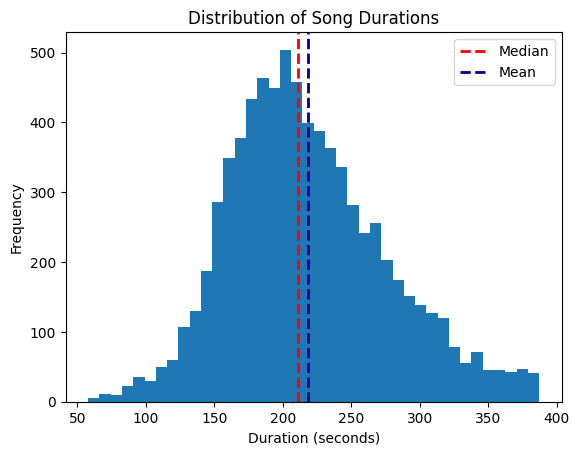

In [37]:
duration = df_clean['duration_sec']
mean = duration.mean()
median = duration.median()


plt.hist(duration,bins=40)
plt.axvline(median, color='red',linestyle='dashed', linewidth=2,label='Median')
plt.axvline(mean, color='darkblue',linestyle='dashed', linewidth=2,label='Mean')
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Song Durations")
plt.legend()
plt.savefig("../eda/duration_histogram.png")
plt.show()

### Rank by Genre

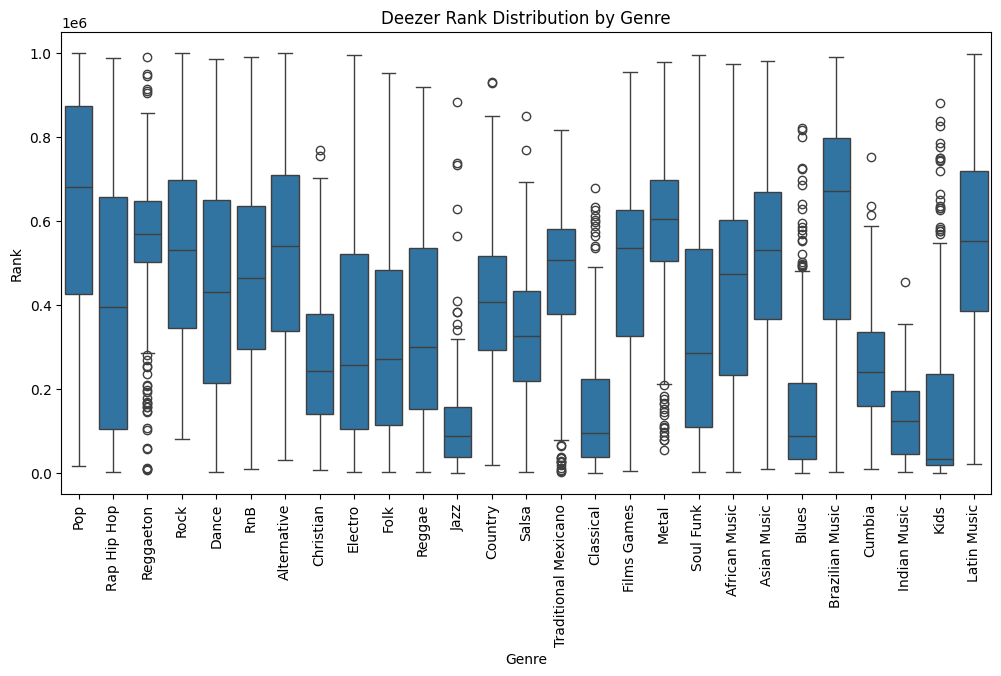

In [38]:
plt.figure(figsize=(12,6))
sns.boxplot(x='genre', y='rank', data=df_clean)

plt.xlabel("Genre")
plt.ylabel("Rank")
plt.xticks(rotation=90)
plt.title("Deezer Rank Distribution by Genre")
plt.savefig("../eda/rank_boxplot.png")
plt.show()

### Song Explicitness

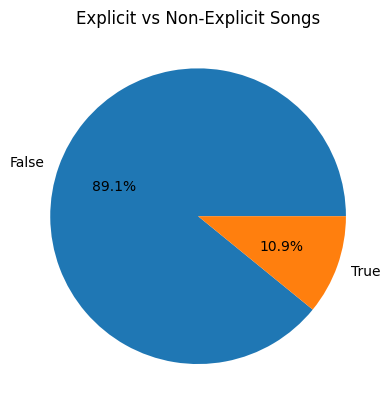

In [39]:
counts = df_clean['explicit'].value_counts()

counts.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")  # removes the default ylabel
plt.title("Explicit vs Non-Explicit Songs")
plt.savefig("../eda/explicit_pie_chart.png")
plt.show()

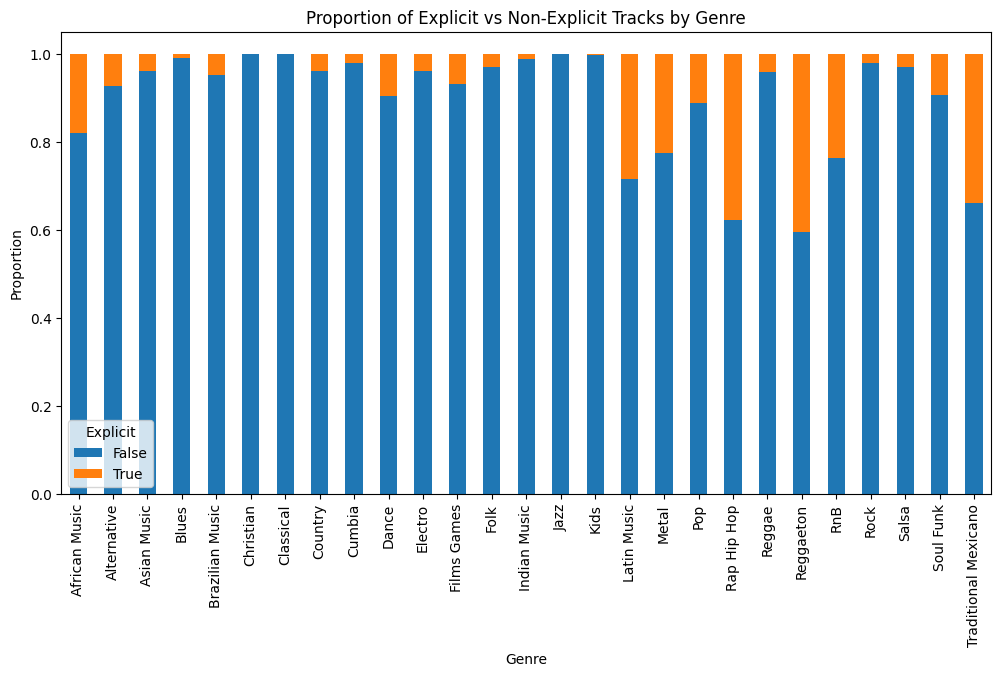

In [40]:
counts = df_clean.groupby(['genre', 'explicit']).size().unstack(fill_value=0)

prop = counts.div(counts.sum(axis=1), axis=0)

prop.plot(kind='bar', stacked=True, figsize=(12,6))
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Proportion")
plt.title("Proportion of Explicit vs Non-Explicit Tracks by Genre")
plt.legend(title="Explicit")

plt.savefig("../eda/explicitness_proportion.png")

plt.show()

## Spectogram

In [41]:
import librosa
import requests
from pydub import AudioSegment
import numpy as np
import os

In [42]:
row = df_clean.iloc[0]

row

genre                   Pop
id               3503857201
title            Man I Need
artist          Olivia Dean
album            Man I Need
duration_sec            184
rank                 991622
explicit              False
Name: 0, dtype: object

In [43]:
fresh = requests.get(f"https://api.deezer.com/track/{row['id']}").json()
preview_url = fresh.get("preview")
if not preview_url:
    print("No preview URL available for this track.")
    exit()

In [44]:
tmp_mp3 = f"tmp_{row['id']}.mp3"
tmp_wav = f"tmp_{row['id']}.wav"
r = requests.get(preview_url)
with open(tmp_mp3, "wb") as f:
    f.write(r.content)

In [45]:
AudioSegment.from_mp3(tmp_mp3).export(tmp_wav, format="wav")
os.remove(tmp_mp3)

In [46]:
y, sr = librosa.load(tmp_wav, sr=22050)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
mel_db = librosa.power_to_db(mel, ref=np.max)

os.remove(tmp_wav)

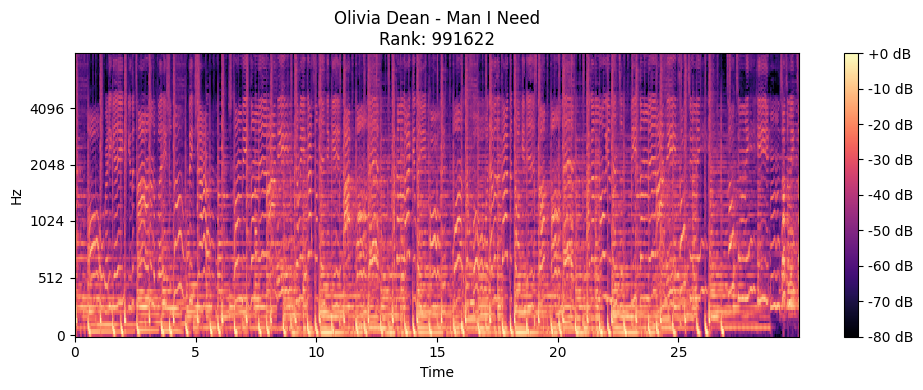

Spectrogram saved → ../data/spectrograms/3503857201.png
Shape: (128, 1292)  (mel bins × time frames)


In [47]:
os.makedirs("../data/spectrograms", exist_ok=True)
out_path = f"../data/spectrograms/{row['id']}.png"

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", fmax=8000)
plt.colorbar(format="%+2.0f dB")
plt.title(f"{row['artist']} - {row['title']}\nRank: {row['rank']}")
plt.tight_layout()
plt.savefig(out_path, dpi=150)
plt.savefig("../eda/sample_spectrogram.png")
plt.show()

print(f"Spectrogram saved → {out_path}")
print(f"Shape: {mel_db.shape}  (mel bins × time frames)")
